Exploratory Data Analysis (EDA)


In [408]:
%matplotlib inline

import numpy as np
import pandas as pd
sales=pd.read_csv('../data/sales.csv')
print("Dataset Head:")
display(sales.head(10))

Dataset Head:


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


In [409]:
sales.sample(12)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
633217,98179,718,5,2014-10-03,0,0,1,a,0,0
74550,686456,899,4,2013-04-25,587,1,1,0,0,5013
101210,33384,1012,5,2013-09-13,557,1,1,0,0,6465
468890,116867,143,5,2013-09-06,464,1,0,0,0,4539
197214,201954,460,5,2014-11-28,416,1,1,0,0,5249
324557,662302,623,3,2014-07-23,679,1,0,0,1,5438
523146,32063,599,5,2015-03-06,947,1,1,0,0,10803
281215,279438,339,2,2013-03-26,811,1,1,0,1,6199
178877,288706,887,4,2013-02-21,562,1,1,0,0,6832
321333,679106,872,3,2014-07-02,906,1,1,0,0,9739


In [410]:
# What are the data types?
print("\nDataset Info:")
sales.info()
# 2. Inspect data types and non-null counts
print("\nDataset Info:")
sales.info()

# 3. Statistical summary of numeric features
print("\nSummary Statistics:")
display(sales.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


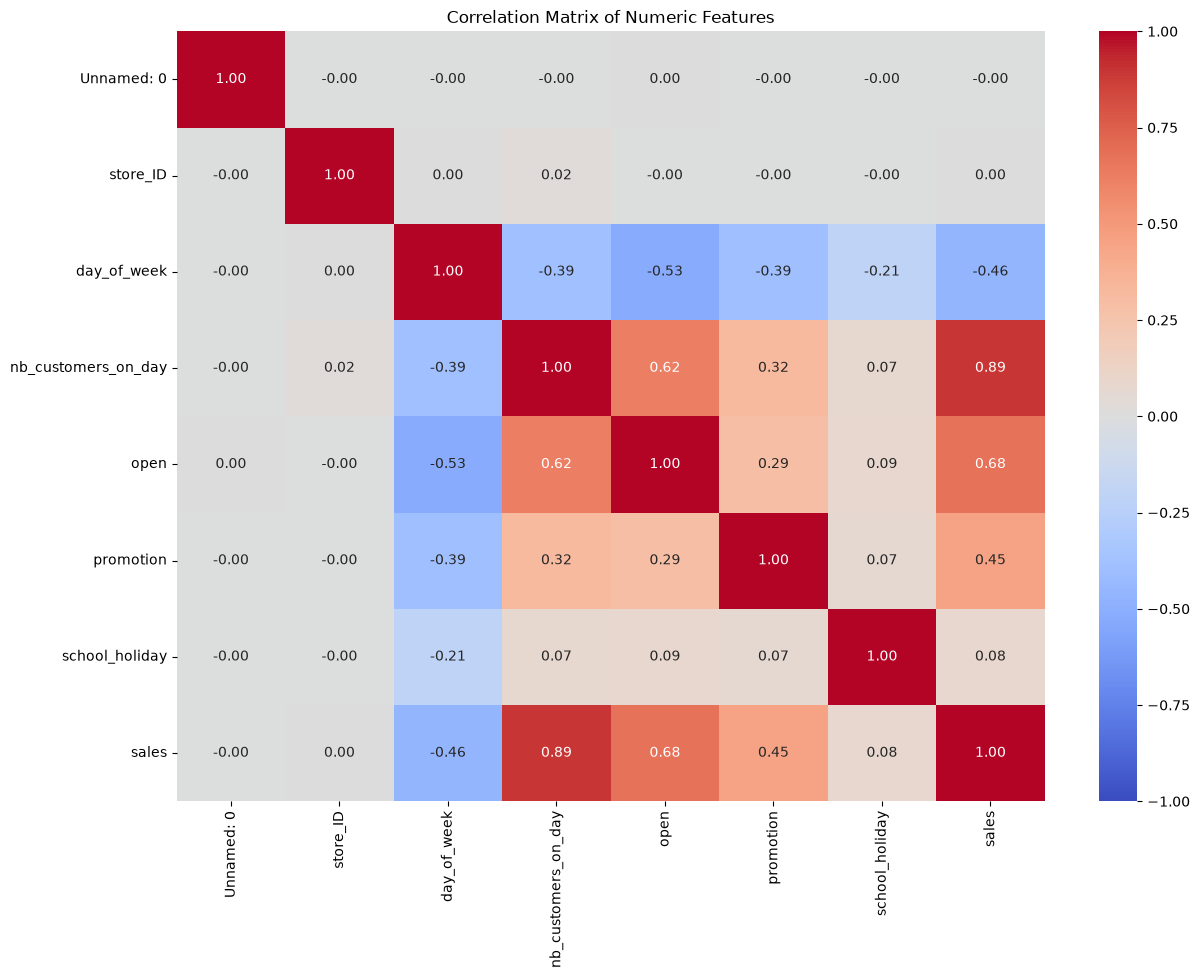

In [411]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

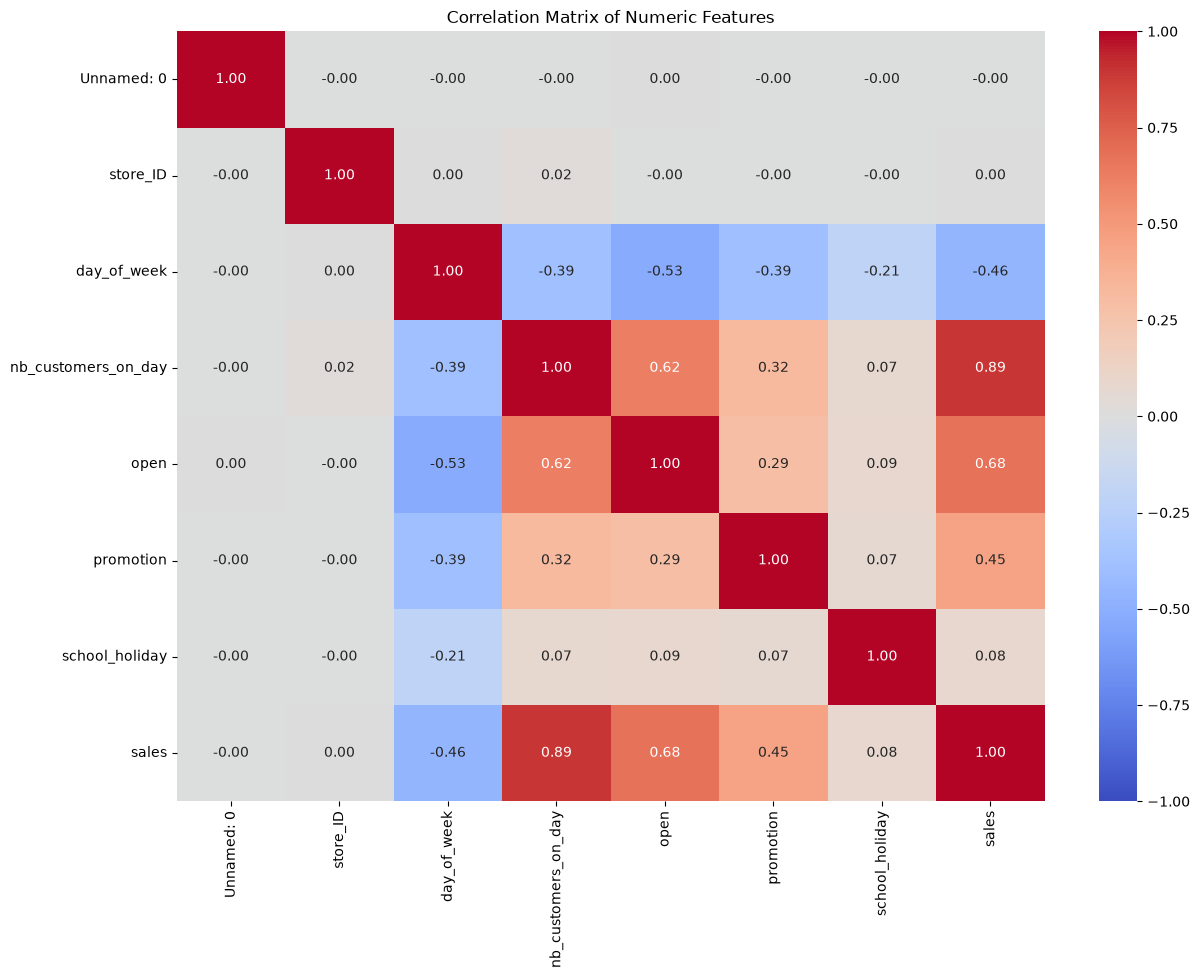

In [412]:
### 1. Code to Generate the Correlation Matrix & Heatmap


# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

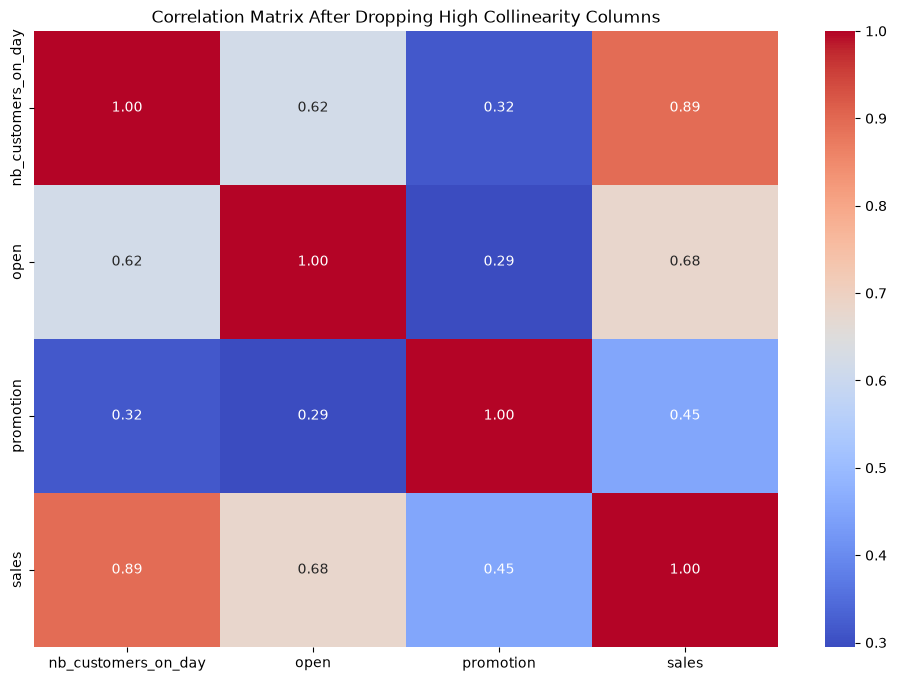

In [413]:
# Drop highly collinear redundant features (>0.90 correlation)
cols_to_drop = [
    "Unnamed: 0",
    "store_ID",
    "day_of_week",
    "school_holiday",
]
sales = sales.drop(columns=cols_to_drop)

# Re-evaluate correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    sales.select_dtypes(include=[np.number]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix After Dropping High Collinearity Columns")
plt.show()

In [414]:
df = pd.read_csv("../data/sales.csv")
df.isna().sum()
print("\nMissing Values Count:")
print(df.isna().sum())


Missing Values Count:
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


What's the target variable : sales 
What features look important : number of customers , promotions , open 
Do you need to handle class imbalance : no imbalance 
Do you need to convert data to the correct data type : not needed so far 
Do you need to handle missing values and/or outliers : no all data present 

In [415]:
from sklearn.linear_model import LinearRegression

In [416]:
from sklearn.model_selection import train_test_split

In [417]:
df_open = df[df['open'] == 1].copy()
df_open['date'] = pd.to_datetime(df_open['date'])
df_open['year'] = df_open['date'].dt.year
df_open['month'] = df_open['date'].dt.month
df_open['day'] = df_open['date'].dt.day

X = df_open.drop(columns=['Unnamed: 0', 'store_ID', 'day_of_week', 'open', 'sales', 'date'])
X = pd.get_dummies(X, columns=['state_holiday'], drop_first=True, dtype=int)
y = df_open['sales']

In [418]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [419]:
print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (372411, 9)
X_val shape:   (79802, 9)
X_test shape:  (79803, 9)


In [420]:
split_class_balance = pd.DataFrame({
    'train (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'validation (%)': (y_val.value_counts(normalize=True) * 100).round(2),
    'test (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})

split_class_balance

,train (%),validation (%),test (%)
sales,,,
0,0.01,0.01,0.0
46,NaN,NaN,0.0
124,0.00,NaN,NaN
316,0.00,NaN,NaN
530,NaN,NaN,0.0
...,...,...,...
38037,NaN,0.00,NaN
38367,NaN,NaN,0.0
38484,NaN,0.00,NaN


In [421]:
print(sales)

              date  nb_customers_on_day  open  promotion state_holiday  sales
0       2013-04-18                  517     1          0             0   4422
1       2015-04-11                  694     1          0             0   8297
2       2013-08-29                  970     1          1             0   9729
3       2013-05-28                  473     1          1             0   6513
4       2013-10-10                 1068     1          1             0  10882
...            ...                  ...   ...        ...           ...    ...
640835  2013-10-26                  483     1          0             0   4553
640836  2014-04-14                  987     1          1             0  12307
640837  2014-07-07                  925     1          0             0   6800
640838  2014-06-12                  725     1          0             0   5344
640839  2015-05-03                    0     0          0             0      0

[640840 rows x 6 columns]


In [422]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [423]:
baseline_model = DummyRegressor(strategy='mean')
_ = baseline_model.fit(X_train, y_train)
print('Baseline prediction:', baseline_model.constant_[0, 0])

Baseline prediction: 6957.196551659323


In [424]:
y_val_pred_baseline = baseline_model.predict(X_val)

In [425]:
baseline_results = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [
        mean_absolute_error(y_val, y_val_pred_baseline),
        np.sqrt(mean_squared_error(y_val, y_val_pred_baseline)),
        r2_score(y_val, y_val_pred_baseline)
    ]
})

baseline_results['value'] = baseline_results['value'].round(3)
baseline_results

,metric,value
0,MAE,2294.768
1,RMSE,3117.658
2,R2,-0.000


In [426]:
y_val.describe()

print("Mean sales:", y_val.mean())
print("Median sales:", y_val.median())
print("Min sales:", y_val.min())
print("Max sales:", y_val.max())

Mean sales: 6966.863512192677
Median sales: 6365.5
Min sales: 0
Max sales: 38484


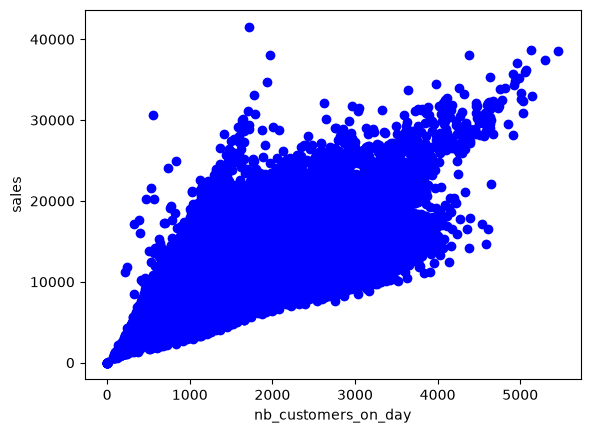

In [427]:
msk = np.random.rand(len(df_open)) < 0.8
train = df_open[msk]
test = df_open[~msk]

plt.scatter(train['nb_customers_on_day'], train['sales'], color='blue')
plt.xlabel("nb_customers_on_day")
plt.ylabel("sales")
plt.show()

In [428]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['nb_customers_on_day']])
train_y = np.asanyarray(train[['sales']])
regr.fit(train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[6.37607872]]
Intercept:  [2093.66117677]


Text(0, 0.5, 'sales')

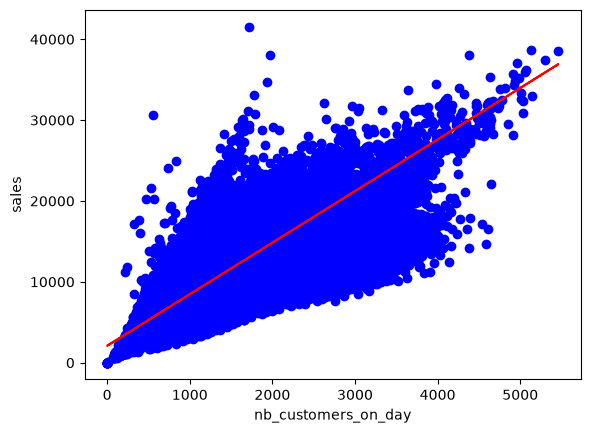

In [429]:
plt.scatter(train.nb_customers_on_day, train.sales,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("nb_customers_on_day")
plt.ylabel("sales")

In [430]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['nb_customers_on_day']])
test_y = np.asanyarray(test[['sales']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y , test_y_) )

Mean absolute error: 1273.15
Residual sum of squares (MSE): 3104171.62
R2-score: 0.68


In [431]:
multi_feature_model = LinearRegression()
multi_feature_model.fit(X_train, y_train)

y_test_pred_multi = multi_feature_model.predict(X_test)

multi_feature_results = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [
        mean_absolute_error(y_test, y_test_pred_multi),
        np.sqrt(mean_squared_error(y_test, y_test_pred_multi)),
        r2_score(y_test, y_test_pred_multi)
    ]
})

multi_feature_results['value'] = multi_feature_results['value'].round(3)
multi_feature_results

,metric,value
0,MAE,1146.187
1,RMSE,1607.904
2,R2,0.730


In [432]:
def predict_sales(data, model=multi_feature_model):
    result = data.copy()
    result['predicted_sales'] = 0.0
    open_mask = result['open'].eq(1)

    if open_mask.any():
        open_data = result.loc[open_mask].copy()
        open_data['date'] = pd.to_datetime(open_data['date'], dayfirst=True)
        open_data['year'] = open_data['date'].dt.year
        open_data['month'] = open_data['date'].dt.month
        open_data['day'] = open_data['date'].dt.day

        open_features = open_data.drop(
            columns=['Unnamed: 0', 'store_ID', 'day_of_week', 'open', 'sales', 'date'],
            errors='ignore'
        )
        open_features = pd.get_dummies(
            open_features,
            columns=['state_holiday'],
            drop_first=True,
            dtype=int
        )
        open_features = open_features.reindex(columns=X.columns, fill_value=0)
        result.loc[open_mask, 'predicted_sales'] = model.predict(open_features)

    return result

example_rows = pd.concat([
    df[df['open'] == 0].head(1),
    df_open.head(1)
]).drop(columns=['sales'])

predict_sales(example_rows)[['open', 'predicted_sales']]

,open,predicted_sales
6,0,0.000000
0,1,4618.966716


In [433]:
inference = pd.read_csv('../data/inference.csv')
inference_predictions = predict_sales(inference)

submission = inference_predictions.drop(columns=['predicted_sales']).copy()
submission['sales'] = inference_predictions['predicted_sales']
submission.to_csv('../group1.csv', index=False)

r2_score_value = float(
    multi_feature_results.loc[multi_feature_results['metric'] == 'R2', 'value'].iloc[0]
)
with open('../group1.txt', 'w', encoding='utf-8') as score_file:
    score_file.write(f'R2: {r2_score_value:.3f}\n')

print('Submission shape:', submission.shape)
print('Submission columns:', submission.columns.tolist())
print('Closed-store predictions:', (submission.loc[submission['open'] == 0, 'sales'] == 0).all())
print('Saved group1.csv and group1.txt')

Submission shape: (71205, 10)
Submission columns: ['index', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day', 'open', 'promotion', 'state_holiday', 'school_holiday', 'sales']
Closed-store predictions: True
Saved group1.csv and group1.txt


In [434]:
from sklearn.tree import DecisionTreeRegressor
import joblib
import os

decision_tree_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
)
decision_tree_model.fit(X_train, y_train)
y_test_pred_tree = decision_tree_model.predict(X_test)
decision_tree_results = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [
        mean_absolute_error(y_test, y_test_pred_tree),
        np.sqrt(mean_squared_error(y_test, y_test_pred_tree)),
        r2_score(y_test, y_test_pred_tree),
    ],
})
decision_tree_results['value'] = decision_tree_results['value'].round(3)
os.makedirs('../models', exist_ok=True)
joblib.dump(decision_tree_model, '../models/decision_tree.joblib')
decision_tree_results

,metric,value
0,MAE,1215.399
1,RMSE,1712.556
2,R2,0.694


In [435]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_test_pred_xgb = xgb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_test_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)))
print("R2:", r2_score(y_test, y_test_pred_xgb))

MAE: 1046.61572265625
RMSE: 1447.1686149167276
R2: 0.7814130783081055


In [436]:
import joblib

xgb_results = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [
        mean_absolute_error(y_test, y_test_pred_xgb),
        np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)),
        r2_score(y_test, y_test_pred_xgb),
    ],
})
xgb_results['value'] = xgb_results['value'].round(3)

joblib.dump(xgb_model, '../models/xgboost_model.joblib')
xgb_inference_predictions = predict_sales(inference, model=xgb_model)
xgb_submission = xgb_inference_predictions.drop(columns=['predicted_sales']).copy()
xgb_submission['sales'] = xgb_inference_predictions['predicted_sales']
xgb_submission.to_csv('../group1.csv', index=False)

xgb_r2 = float(xgb_results.loc[xgb_results['metric'] == 'R2', 'value'].iloc[0])
with open('../group1.txt', 'w', encoding='utf-8') as score_file:
    score_file.write(str(xgb_r2) + '\n')

print('XGBoost submission shape:', xgb_submission.shape)
print('Closed-store predictions:', (xgb_submission.loc[xgb_submission['open'] == 0, 'sales'] == 0).all())
xgb_results

XGBoost submission shape: (71205, 10)
Closed-store predictions: True


,metric,value
0,MAE,1046.616
1,RMSE,1447.169
2,R2,0.781


In [ ]:
submission_check = pd.read_csv('../group1.csv')
inference_columns = pd.read_csv('../data/inference.csv', nrows=0).columns.tolist()
expected_columns = inference_columns + ['sales']

print('Columns correct:', submission_check.columns.tolist() == expected_columns)
print('Row count:', len(submission_check))
print('Inference row count:', len(inference))
print('Closed-store predictions are zero:', (submission_check.loc[submission_check['open'] == 0, 'sales'] == 0).all())
print('Negative predictions:', (submission_check['sales'] < 0).sum())
print('Sales summary:')
display(submission_check['sales'].describe())
print('Sample predictions:')
display(submission_check.sample(5, random_state=42))

We trained three models linear regression , decision Tree and finally Xgboost.
The best model that performed was Xgboost and the results of this model are saved in this group1.csv file 
